


## ML Capstone Project — Review 1

**Group Name:** H2P

### Problem Type
**Regression**

### Dataset
# Medical Insurance Cost Prediction Using Regression

This notebook develops a complete machine learning regression pipeline to predict medical insurance charges based on demographic and lifestyle-related features. The workflow includes dataset loading, exploratory data analysis, data cleaning, feature engineering, preprocessing, training multiple regression algorithms, model comparison, hyperparameter tuning, cross-validation, and final model analysis.

The target variable for this regression problem is `charges`, which represents the medical insurance cost for an individual.

## Importing Required Libraries

The required Python libraries are imported to perform data manipulation, visualization, preprocessing, model development, evaluation, and hyperparameter tuning.

Pandas and NumPy are used for data handling and numerical operations. Matplotlib and Seaborn are used for exploratory data analysis and visualization. Scikit-learn provides preprocessing techniques, regression algorithms, evaluation metrics, cross-validation, and hyperparameter tuning utilities.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset

The medical insurance dataset is loaded from the CSV file using Pandas. After loading the dataset, the shape and first few records are displayed to verify that the data has been read correctly and to obtain an initial understanding of its structure.

In [4]:
df = pd.read_csv("../data/insurance.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0,yes,southwest,16884.92400
1,18.0,male,33.770,1,no,southeast,1725.55230
2,28.0,male,33.000,3,no,southeast,4449.46200
3,33.0,male,22.705,0,no,northwest,21984.47061
4,32.0,male,28.880,0,no,northwest,3866.85520


## Dataset Audit

A preliminary audit is performed to understand the structure and quality of the dataset. The dataset shape, column names, data types, missing values, duplicate records, and statistical summary are examined.

This step helps identify the available features, understand the type of each variable, and detect potential data-quality issues that may need to be addressed before model training.

In [5]:
print("Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe(include="all"))

Shape:
(1338, 7)

Column Names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data Types:
age         float64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
age         2
sex         1
bmi         2
children    0
smoker      1
region      2
charges     0
dtype: int64

Duplicate Rows:
1

Statistical Summary:


,age,sex,bmi,children,smoker,region,charges
count,1336.000000,1337,1336.000000,1338.000000,1337,1336,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,675,NaN,NaN,1064,364,NaN
mean,39.225299,NaN,30.653447,1.094918,NaN,NaN,13270.422265
std,14.048210,NaN,6.096546,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.272500,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.380000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.618750,2.000000,NaN,NaN,16639.912515


## Identifying the Target Variable

The objective of this regression problem is to predict medical insurance charges. Therefore, `charges` is selected as the target variable.

The descriptive statistics of the target variable are examined to understand its range, central tendency, and variability before building the regression models.

In [6]:
target = "charges"

print("Target column:", target)

print("\nTarget statistics:")
print(df[target].describe())

Target column: charges

Target statistics:
count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64


## Identifying Numerical and Categorical Features

The dataset contains both numerical and categorical variables. Numerical features represent measurable quantities, while categorical features represent groups or categories.

Identifying these feature types is important because they require different preprocessing techniques before being supplied to machine learning algorithms.

In [7]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['sex', 'smoker', 'region']

Numerical columns:
['age', 'bmi', 'children', 'charges']


## Exploratory Data Analysis: Numerical Feature Distributions

The distributions of the numerical features are visualized using histograms with kernel density estimates. These plots help examine the spread, concentration, and possible skewness of each numerical variable.

Understanding the distributions is useful for identifying unusual patterns and deciding whether further preprocessing or transformation may be required.

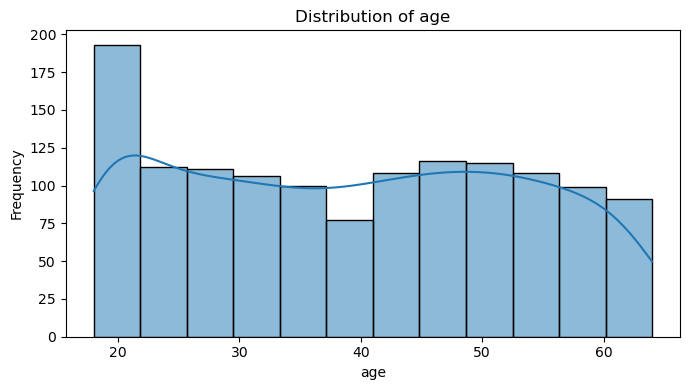

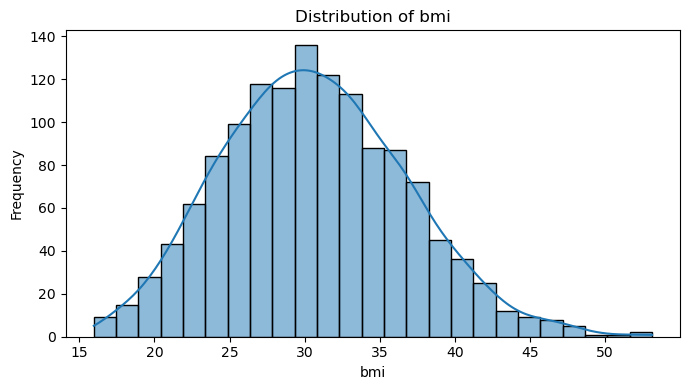

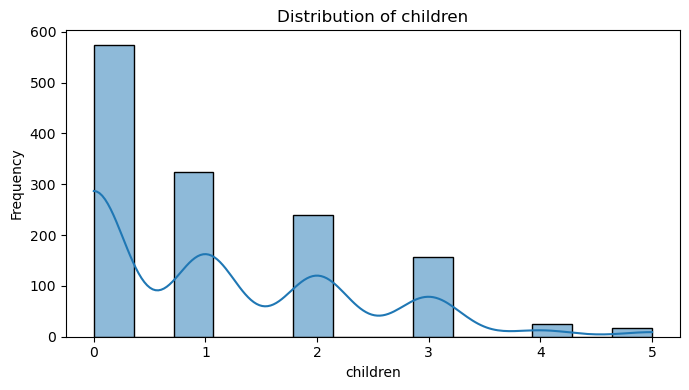

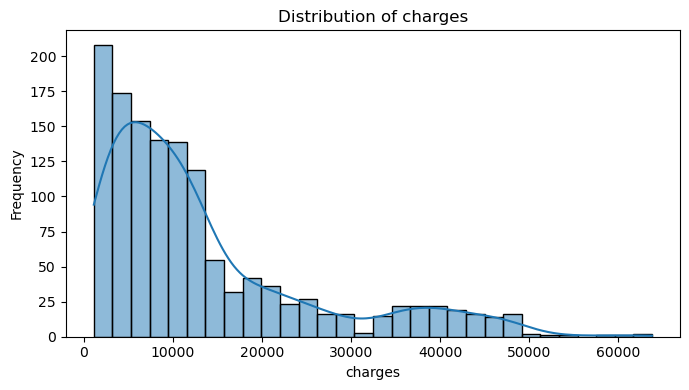

In [8]:
for column in numerical_columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Observation

The age distribution is spread across the adult age range from 18 to 64 years. BMI values are mainly concentrated around the middle range, while a smaller number of observations have very low or very high BMI values. The number of children is concentrated mainly at 0, 1, and 2 children.

## Distribution of Categorical Features

The categorical features are visualized using count plots to examine the number of observations belonging to each category.

This analysis helps determine whether the categorical variables contain balanced or unevenly distributed groups and provides an initial understanding of the composition of the dataset.

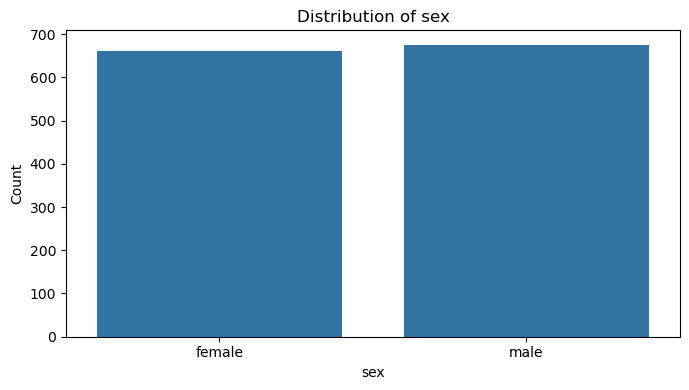

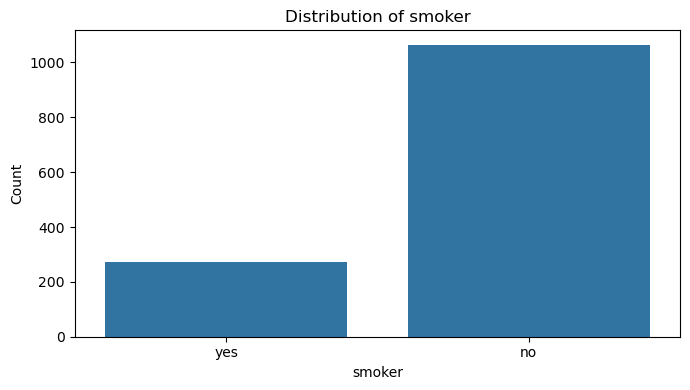

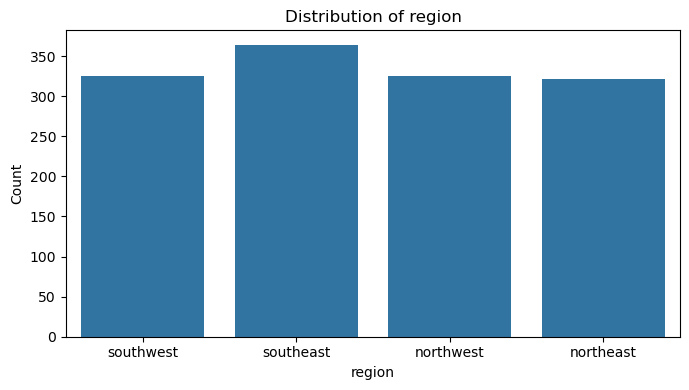

In [9]:
for column in categorical_columns:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=column)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### Observation

The sex variable contains two categories with relatively similar frequencies. The smoker variable is dominated by non-smokers. The region variable contains four categories, with some regions having more observations than others.

## Distribution of Medical Insurance Charges

The distribution of the target variable, `charges`, is visualized to understand how medical insurance costs are distributed across the dataset.

Examining the target distribution is important because the shape and spread of the target variable can influence regression model performance.

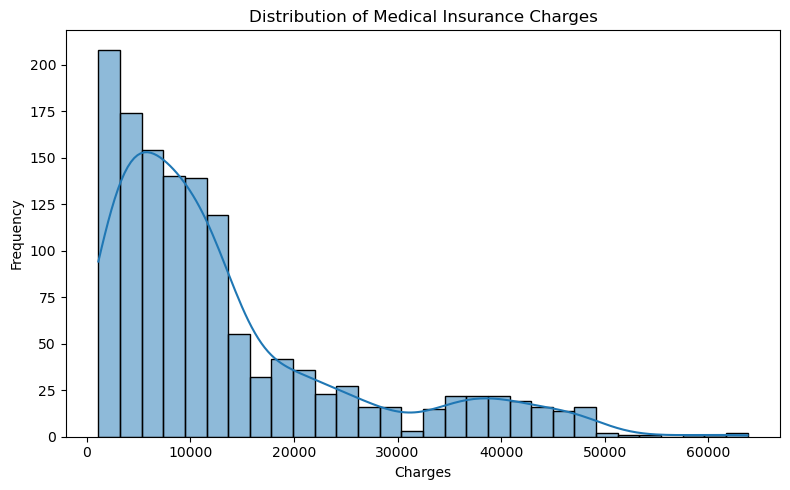

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df["charges"], kde=True)
plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Observation

The distribution of medical insurance charges is right-skewed. Most observations have relatively lower charges, while a smaller number of individuals have substantially higher charges, creating a long right tail.

## Correlation Analysis

A correlation heatmap is used to examine the linear relationships between the numerical variables in the dataset.

Correlation values provide an initial indication of how strongly numerical features are associated with one another and with the target variable, `charges`. This analysis helps identify potentially important relationships before model development.

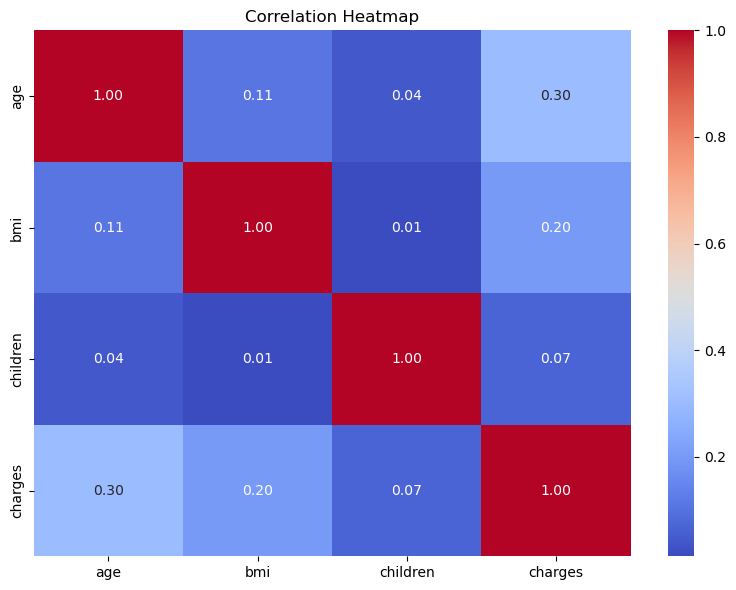

In [11]:
plt.figure(figsize=(8, 6))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Relationship Between Age and Medical Insurance Charges

A scatter plot is used to investigate the relationship between age and medical insurance charges.

This visualization helps determine whether changes in age appear to be associated with changes in the target variable and whether the relationship appears approximately linear or contains other patterns.

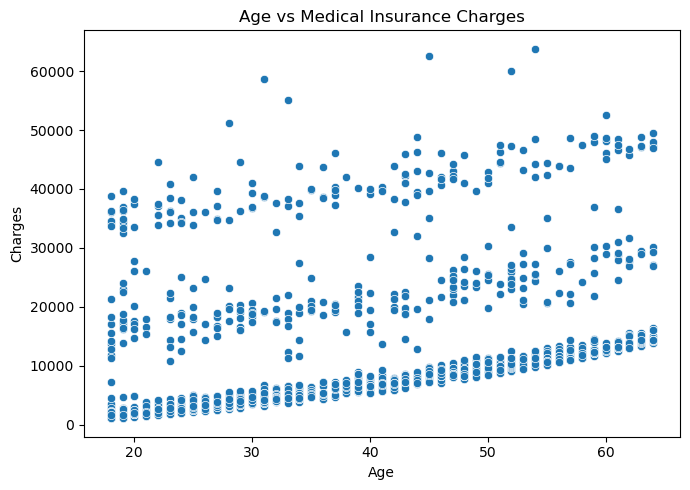

In [12]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="age", y="charges")
plt.title("Age vs Medical Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()

### Observation

The scatter plot indicates a positive relationship between age and medical insurance charges. In general, charges tend to increase as age increases, although there is considerable variation in charges for individuals of similar ages.

## Relationship Between BMI and Medical Insurance Charges

A scatter plot is used to examine the relationship between BMI and medical insurance charges.

The visualization helps determine whether BMI shows an observable association with insurance charges and whether the relationship appears uniform across the range of BMI values.

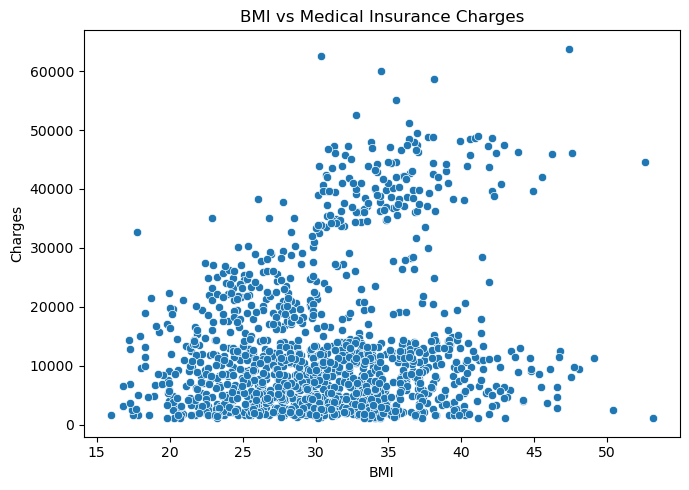

In [13]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="bmi", y="charges")
plt.title("BMI vs Medical Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()

### Observation

The scatter plot shows a positive but weaker relationship between BMI and medical insurance charges. Higher BMI values are associated with a wider range of charges, indicating that BMI alone does not fully explain the variation in insurance costs.

## Data Cleaning

Before training the regression models, the dataset is checked for common data-quality issues such as missing values, duplicate records, and potential outliers.

Cleaning the dataset helps ensure that the models are trained using reliable and consistent observations.

### Missing Values and Duplicate Records

The dataset is checked for missing values and duplicate rows. Missing values can cause problems during model training, while duplicate records may give excessive importance to repeated observations.

The results of these checks are used to determine the appropriate preprocessing and cleaning actions.

### Missing-Value Handling

Numerical missing values are handled using median imputation, while categorical missing values are handled using the most-frequent category. These transformations are included inside the preprocessing pipeline so that the preprocessing steps are learned from the training data.

In [14]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
age         2
sex         1
bmi         2
children    0
smoker      1
region      2
charges     0
dtype: int64

Duplicate rows:
1


In [15]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1337, 7)


## Outlier Analysis

Box plots are used to identify potential outliers in the numerical variables. Outliers are examined before model training because extreme observations can influence regression models and evaluation metrics.

Potential outliers are not automatically removed because an unusually high or low medical charge may represent a genuine observation rather than an incorrect data entry. Therefore, the detected observations are evaluated in the context of the dataset before deciding whether removal is appropriate.

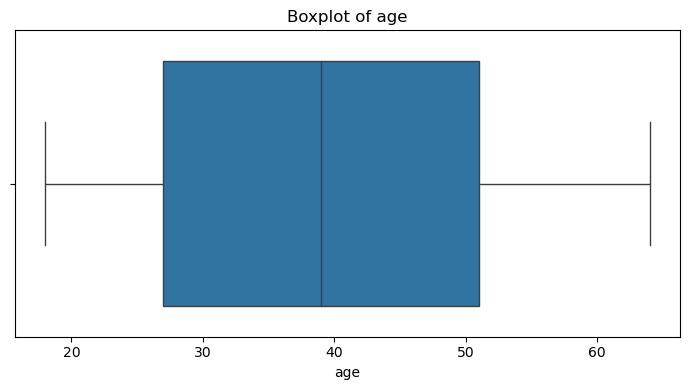

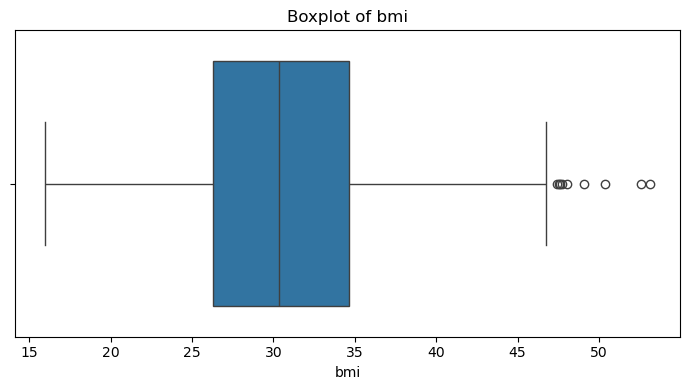

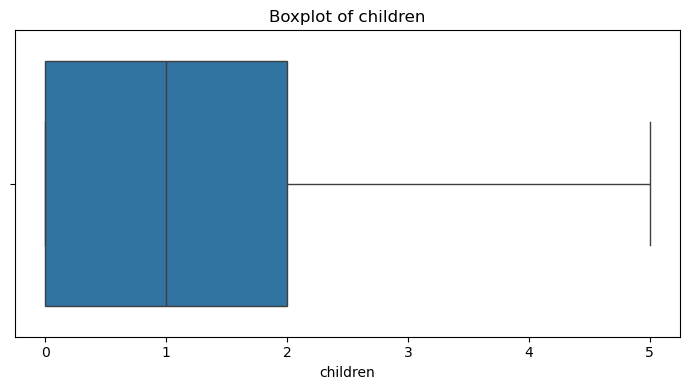

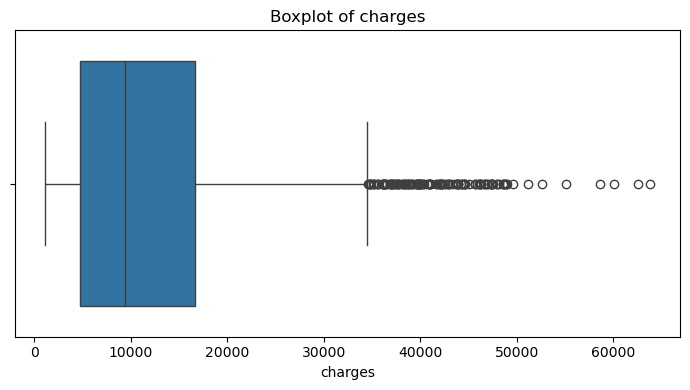

In [16]:
for column in ["age", "bmi", "children", "charges"]:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

### Observation and Treatment Decision

The box plots were examined for potential extreme observations. Based on the observed data, the identified values are treated as potential valid observations rather than automatically removing them. The decision is documented based on the characteristics of the medical insurance dataset.

## Feature Engineering

A new feature named `bmi_age` is created by multiplying BMI and age.

This interaction feature is introduced to represent the combined effect of age and BMI rather than treating the two variables only as independent predictors. The engineered feature is then included in the regression models to determine whether this additional representation provides useful predictive information.

In [17]:
df["bmi_age"] = df["bmi"] * df["age"]

print("New feature created: bmi_age")

display(df.head())

New feature created: bmi_age


,age,sex,bmi,children,smoker,region,charges,bmi_age
0,19.0,female,27.900,0,yes,southwest,16884.92400,530.100
1,18.0,male,33.770,1,no,southeast,1725.55230,607.860
2,28.0,male,33.000,3,no,southeast,4449.46200,924.000
3,33.0,male,22.705,0,no,northwest,21984.47061,749.265
4,32.0,male,28.880,0,no,northwest,3866.85520,924.160


### Feature Engineering Result

The new `bmi_age` feature has been added to the dataset. Its usefulness will be evaluated indirectly through the performance of the regression models.

## Separating Features and Target

The dataset is divided into predictor variables (`X`) and the target variable (`y`).

The target variable `charges` is removed from `X` because it is the value that the regression models are expected to predict. All remaining variables are used as input features.

In [18]:
X = df.drop("charges", axis=1)
y = df["charges"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1337, 7)
y shape: (1337,)


## Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 split. The training set is used to learn the model parameters, while the held-out testing set is used to evaluate model performance.

A fixed `random_state` of 42 is used to make the split reproducible. Stratification is performed using bins created from the continuous target variable so that the distribution of the target is reasonably represented in both subsets.

In [19]:
y_bins = pd.qcut(
    y,
    q=5,
    labels=False,
    duplicates="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_bins
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1069, 7)
Testing data: (268, 7)


## Data Preprocessing

The numerical and categorical features require different preprocessing operations.

Numerical features are processed using median imputation followed by standardization. Categorical features are processed using most-frequent imputation followed by one-hot encoding.

These transformations are combined using a `ColumnTransformer` so that the appropriate preprocessing is automatically applied to each feature type.

### Preventing Data Leakage

The preprocessing operations are included inside the machine learning pipeline. This ensures that the imputation, scaling, and encoding parameters are learned from the training data when the model is fitted.

The fitted transformations are then applied to the test data without using information from the test set during training. This prevents data leakage and provides a fair evaluation of model performance.

In [20]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'bmi', 'children', 'bmi_age']

Categorical features:
['sex', 'smoker', 'region']


In [21]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Regression Model Development

Ten regression algorithms specified in the project guidelines are implemented and evaluated on the same training and held-out testing datasets.

The models represent different regression approaches, including linear models, regularized models, polynomial regression, tree-based models, ensemble methods, support vector regression, and distance-based regression.

The required algorithms are:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet
5. Polynomial Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor
10. K-Nearest Neighbors Regressor

In [22]:
models = {
    "Linear Regression": LinearRegression(),
    
    "Ridge": Ridge(alpha=1.0),
    
    "Lasso": Lasso(alpha=0.1),
    
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    
    "Polynomial Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("linear", LinearRegression())
    ]),
    
    "Decision Tree": DecisionTreeRegressor(
        random_state=42,
        max_depth=None
    ),
    
    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_estimators=100
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    
    "SVR": SVR(
        kernel="rbf",
        C=100
    ),
    
    "KNN": KNeighborsRegressor(
        n_neighbors=5
    )
}

print("Number of models:", len(models))

Number of models: 10


### Linear Regression - Coefficient Interpretation

Linear Regression is used as the baseline model. The coefficients indicate how the predicted medical insurance charges change with respect to the corresponding features, while keeping other features constant.

Positive coefficients indicate an increase in predicted charges, while negative coefficients indicate a decrease.

In [62]:
linear_model = trained_models["Linear Regression"]

feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = linear_model.named_steps["model"].coef_

linear_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

display(
    linear_coef_df.sort_values(
        by="Coefficient",
        ascending=False
    )
)

,Feature,Coefficient
7,cat__smoker_yes,11825.362711
0,num__age,3174.093520
1,num__bmi,1796.680514
2,num__children,604.719857
8,cat__region_northeast,542.025769
3,num__bmi_age,515.902320
9,cat__region_northwest,188.304597
4,cat__sex_female,43.641856
5,cat__sex_male,-43.641856
11,cat__region_southwest,-116.854937


### Ridge Regression - Alpha Tuning

Different alpha values were compared to observe the effect of L2 regularisation. The alpha value controls the strength of regularisation.

In [55]:
ridge_alphas = [0.01, 0.1, 1, 10, 100]

ridge_results = []

for alpha in ridge_alphas:
    ridge_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=alpha))
    ])
    
    ridge_pipeline.fit(X_train, y_train)
    ridge_pred = ridge_pipeline.predict(X_test)
    
    ridge_results.append({
        "Alpha": alpha,
        "R2": r2_score(y_test, ridge_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, ridge_pred)),
        "MAE": mean_absolute_error(y_test, ridge_pred)
    })

ridge_results_df = pd.DataFrame(ridge_results)
display(ridge_results_df)

,Alpha,R2,RMSE,MAE
0,0.01,0.727616,6370.020673,4407.763368
1,0.10,0.727601,6370.193848,4408.223513
2,1.00,0.727451,6371.954281,4412.799508
3,10.00,0.725694,6392.453840,4457.607609
4,100.00,0.687765,6820.107607,4917.698736


### Lasso Regression - Feature Sparsity

Lasso uses L1 regularisation. Some feature coefficients may become exactly zero, which results in a sparse model and can effectively remove less important features.

In [56]:
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1))
])

lasso_pipeline.fit(X_train, y_train)

feature_names = lasso_pipeline.named_steps["preprocessor"].get_feature_names_out()
lasso_coefficients = lasso_pipeline.named_steps["model"].coef_

lasso_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_coefficients
})

lasso_coef_df["Absolute Coefficient"] = lasso_coef_df["Coefficient"].abs()

display(lasso_coef_df.sort_values("Absolute Coefficient", ascending=False))

zero_coefficients = (lasso_coefficients == 0).sum()

print("Number of zero coefficients:", zero_coefficients)
print("Total number of coefficients:", len(lasso_coefficients))

,Feature,Coefficient,Absolute Coefficient
6,cat__smoker_no,-2.365004e+04,2.365004e+04
0,num__age,3.173777e+03,3.173777e+03
1,num__bmi,1.796350e+03,1.796350e+03
8,cat__region_northeast,6.583445e+02,6.583445e+02
2,num__children,6.046242e+02,6.046242e+02
3,num__bmi_age,5.162255e+02,5.162255e+02
10,cat__region_southeast,-4.963285e+02,4.963285e+02
9,cat__region_northwest,3.045747e+02,3.045747e+02
4,cat__sex_female,8.682445e+01,8.682445e+01
7,cat__smoker_yes,8.976826e-10,8.976826e-10


Number of zero coefficients: 1
Total number of coefficients: 12


### ElasticNet - L1 Ratio Tuning

The l1_ratio controls the balance between L1 and L2 regularisation. Different values were compared to observe their effect on model performance.

In [57]:
l1_ratios = [0.1, 0.5, 0.9]

elasticnet_results = []

for ratio in l1_ratios:
    elastic_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", ElasticNet(alpha=0.1, l1_ratio=ratio))
    ])
    
    elastic_pipeline.fit(X_train, y_train)
    elastic_pred = elastic_pipeline.predict(X_test)
    
    elasticnet_results.append({
        "L1 Ratio": ratio,
        "R2": r2_score(y_test, elastic_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, elastic_pred)),
        "MAE": mean_absolute_error(y_test, elastic_pred)
    })

elasticnet_results_df = pd.DataFrame(elasticnet_results)
display(elasticnet_results_df)

,L1 Ratio,R2,RMSE,MAE
0,0.1,0.689801,6797.832500,4898.273667
1,0.5,0.710906,6562.506859,4675.605114
2,0.9,0.725542,6394.231813,4460.987953


In [58]:
polynomial_results = []

for degree in [2, 3]:
    poly_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linear", LinearRegression())
    ])
    
    poly_pipeline.fit(X_train, y_train)
    poly_pred = poly_pipeline.predict(X_test)
    
    polynomial_results.append({
        "Degree": degree,
        "R2": r2_score(y_test, poly_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, poly_pred)),
        "MAE": mean_absolute_error(y_test, poly_pred)
    })

polynomial_results_df = pd.DataFrame(polynomial_results)
display(polynomial_results_df)

,Degree,R2,RMSE,MAE
0,2,0.812147,5290.045001,3187.611629
1,3,0.781585,5704.159117,3532.603056


### Decision Tree Regressor - Max Depth Tuning

Decision Tree Regression was evaluated using different maximum tree depths. Increasing the depth allows the model to capture more complex relationships in the data, but very deep trees may lead to overfitting. Therefore, different `max_depth` values were compared to find a suitable tree complexity.


In [59]:
tree_depths = [3, 5, 10, None]

tree_results = []

for depth in tree_depths:
    tree_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=42,
            max_depth=depth
        ))
    ])
    
    tree_pipeline.fit(X_train, y_train)
    tree_pred = tree_pipeline.predict(X_test)
    
    tree_results.append({
        "Max Depth": depth,
        "R2": r2_score(y_test, tree_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, tree_pred)),
        "MAE": mean_absolute_error(y_test, tree_pred)
    })

tree_results_df = pd.DataFrame(tree_results)
display(tree_results_df)

,Max Depth,R2,RMSE,MAE
0,3.0,0.821799,5152.353366,3042.907702
1,5.0,0.828659,5052.196518,2721.727526
2,10.0,0.721518,6440.937552,3141.470169
3,NaN,0.713774,6529.873075,3060.588888


### SVR - C and Kernel Comparison

Different values of C and different kernels were compared. Feature scaling is important for SVR because it is sensitive to the scale of the input features. The preprocessing pipeline applies StandardScaler to the numerical features.

In [60]:
svr_results = []

for C in [1, 10, 100]:
    for kernel in ["linear", "rbf"]:
        svr_pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", SVR(C=C, kernel=kernel))
        ])

        svr_pipeline.fit(X_train, y_train)
        svr_pred = svr_pipeline.predict(X_test)

        svr_results.append({
            "C": C,
            "Kernel": kernel,
            "R2": r2_score(y_test, svr_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, svr_pred)),
            "MAE": mean_absolute_error(y_test, svr_pred)
        })

svr_results_df = pd.DataFrame(svr_results)
display(svr_results_df)

,C,Kernel,R2,RMSE,MAE
0,1,linear,-0.068050,12613.802173,7769.624467
1,1,rbf,-0.095084,12772.439472,8284.769673
2,10,linear,0.069815,11771.583881,5900.836775
3,10,rbf,-0.078174,12673.445867,7965.420134
4,100,linear,0.534069,8331.265889,3910.050338
5,100,rbf,0.017716,12096.750695,6186.195800


### KNN Regression - K Comparison

Different values of k were compared to evaluate their effect on model performance. KNN is a distance-based algorithm, so feature scaling is important. In this project, StandardScaler is used in the preprocessing pipeline so that features with larger numerical ranges do not dominate the distance calculation.

In [61]:
knn_results = []

for k in [3, 5, 7, 9]:
    knn_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsRegressor(n_neighbors=k))
    ])

    knn_pipeline.fit(X_train, y_train)
    knn_pred = knn_pipeline.predict(X_test)

    knn_results.append({
        "K": k,
        "R2": r2_score(y_test, knn_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, knn_pred)),
        "MAE": mean_absolute_error(y_test, knn_pred)
    })

knn_results_df = pd.DataFrame(knn_results)
display(knn_results_df)

,K,R2,RMSE,MAE
0,3,0.681001,6893.585859,3793.259441
1,5,0.706021,6617.715206,3813.951475
2,7,0.699644,6689.112215,4013.094687
3,9,0.675744,6950.146182,4097.651475


## Training and Evaluating the Regression Models

Each regression algorithm is integrated with the same preprocessing pipeline and trained using the training dataset.

Predictions are generated for the same held-out test set. Three evaluation metrics are calculated for every model: R², RMSE, and MAE.

Using the same test set for all models makes the comparison consistent and allows the relative performance of the algorithms to be examined fairly.

In [23]:
results = []

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,R2,RMSE,MAE
0,Gradient Boosting,0.833127,4985.898240,2731.893656
1,Random Forest,0.829627,5037.917140,2764.523710
2,Polynomial Regression,0.812147,5290.045001,3187.611629
3,Linear Regression,0.727618,6370.001463,4407.712211
4,Lasso,0.727617,6370.009604,4407.737973
5,Ridge,0.727451,6371.954281,4412.799508
6,Decision Tree,0.713774,6529.873075,3060.588888
7,ElasticNet,0.710906,6562.506859,4675.605114
8,KNN,0.706021,6617.715206,3813.951475
9,SVR,0.017716,12096.750695,6186.195800


## Hyperparameter Tuning: Random Forest Regressor

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to produce a more robust prediction. In this stage, GridSearchCV is used to identify a suitable combination of hyperparameters for the Random Forest model.

The hyperparameters considered for tuning are the number of trees (`n_estimators`), maximum tree depth (`max_depth`), and minimum number of samples required to split an internal node (`min_samples_split`).

Five-fold cross-validation is used during GridSearchCV, and the model is selected based on the R² score. After tuning, the optimized model is evaluated on the same held-out test set used for the baseline models.

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Random Forest pipeline
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

# Hyperparameter grid
rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

# GridSearchCV
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train GridSearchCV
rf_grid.fit(X_train, y_train)

# Predictions using tuned model
rf_pred = rf_grid.predict(X_test)

# Tuned model evaluation
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

# Baseline Random Forest R2
baseline_rf_r2 = results_df.loc[
    results_df["Model"] == "Random Forest",
    "R2"
].values[0]

# Calculate improvement
rf_r2_improvement = rf_r2 - baseline_rf_r2

# Display results
print("Random Forest Best Parameters:")
print(rf_grid.best_params_)

print("\nRandom Forest Tuned Results:")
print("R2:", rf_r2)
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)

print("\nRandom Forest R2 Improvement:")
print(rf_r2_improvement)

Random Forest Best Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Random Forest Tuned Results:
R2: 0.8336005066390753
RMSE: 4978.817487048056
MAE: 2733.7435885149744

Random Forest R2 Improvement:
0.003973842801936023


### Random Forest Tuning Result

The GridSearchCV process identified the hyperparameter combination that produced the highest cross-validated R² score. The tuned Random Forest was then evaluated on the held-out test set using R², RMSE, and MAE.

The R² improvement is calculated by comparing the tuned Random Forest with the baseline Random Forest. A positive improvement indicates that the tuned model achieved a higher R² score than the baseline model, while a negative value indicates a decrease in R².

## Hyperparameter Tuning: Gradient Boosting Regressor

Gradient Boosting Regressor is an ensemble learning algorithm that builds multiple decision trees sequentially. Each new tree tries to reduce the errors made by the previous trees.

GridSearchCV is used to find the best combination of hyperparameters for the Gradient Boosting Regressor.

The hyperparameters tuned are:
- `n_estimators`: Number of boosting trees.
- `learning_rate`: Controls the contribution of each tree.
- `max_depth`: Maximum depth of each decision tree.

Five-fold cross-validation is used during GridSearchCV, and R² score is used as the scoring metric.

The tuned model is evaluated on the same held-out test set used for the other regression models.

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)

gb_params = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

gb_pred = gb_grid.predict(X_test)

gb_r2 = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)

baseline_gb_r2 = results_df.loc[
    results_df["Model"] == "Gradient Boosting",
    "R2"
].values[0]

gb_r2_improvement = gb_r2 - baseline_gb_r2

print("Gradient Boosting Best Parameters:")
print(gb_grid.best_params_)

print("\nGradient Boosting Tuned Results:")
print("R2:", gb_r2)
print("RMSE:", gb_rmse)
print("MAE:", gb_mae)

print("\nGradient Boosting R2 Improvement:")
print(gb_r2_improvement)

Gradient Boosting Best Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}

Gradient Boosting Tuned Results:
R2: 0.8385076320818675
RMSE: 4904.855391064217
MAE: 2750.999289664885

Gradient Boosting R2 Improvement:
0.005380760617449742


### Gradient Boosting Tuning Result

GridSearchCV identified the hyperparameter combination that produced the highest cross-validated R² score.

The tuned Gradient Boosting model was evaluated on the held-out test set using R², RMSE, and MAE.

The R² improvement is calculated by comparing the tuned Gradient Boosting model with the baseline Gradient Boosting model.

A positive R² improvement indicates that the tuned model performed better than the baseline model, while a negative value indicates a decrease in R².

In [38]:
print("Baseline Gradient Boosting R2:", baseline_gb_r2)
print("Tuned Gradient Boosting R2:", gb_r2)
print("R2 Improvement:", gb_r2_improvement)

Baseline Gradient Boosting R2: 0.8331268714644178
Tuned Gradient Boosting R2: 0.8385076320818675
R2 Improvement: 0.005380760617449742


## Comparison of Regression Models

The performance of all regression algorithms is compared using R², RMSE, and MAE. The models are ranked according to their R² score, where a higher R² indicates better predictive performance.

In [39]:
results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,R2,RMSE,MAE
0,Gradient Boosting,0.833127,4985.898240,2731.893656
1,Random Forest,0.829627,5037.917140,2764.523710
2,Polynomial Regression,0.812147,5290.045001,3187.611629
3,Linear Regression,0.727618,6370.001463,4407.712211
4,Lasso,0.727617,6370.009604,4407.737973
5,Ridge,0.727451,6371.954281,4412.799508
6,Decision Tree,0.713774,6529.873075,3060.588888
7,ElasticNet,0.710906,6562.506859,4675.605114
8,KNN,0.706021,6617.715206,3813.951475
9,SVR,0.017716,12096.750695,6186.195800


## Top Two Regression Models

The regression models are ranked according to their R² score on the held-out test set.

The two models with the highest R² scores are selected for five-fold cross-validation. Cross-validation is used to evaluate the consistency of their performance across different subsets of the training data.

In [41]:
top_model_names = results_df.head(2)["Model"].tolist()

print("Top 2 Regression Models:")
for i, model in enumerate(top_model_names, start=1):
    print(f"{i}. {model}")

Top 2 Regression Models:
1. Gradient Boosting
2. Random Forest


## Five-Fold Cross-Validation of Top Two Models

Five-fold cross-validation is performed on the two best-performing regression models.

The training data is divided into five folds. The model is trained on four folds and validated on the remaining fold. This process is repeated five times so that every fold is used once for validation.

The mean R² score and standard deviation are reported to show the average performance and consistency of each model.

In [42]:
from sklearn.model_selection import cross_val_score

cv_results = []

for model_name in top_model_names:
    
    if model_name == "Random Forest":
        model_pipeline = rf_grid.best_estimator_
        
    elif model_name == "Gradient Boosting":
        model_pipeline = gb_grid.best_estimator_
        
    else:
        model_pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", models[model_name])
        ])
    
    cv_scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    
    cv_results.append({
        "Model": model_name,
        "CV Mean R2": cv_scores.mean(),
        "CV Std R2": cv_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

,Model,CV Mean R2,CV Std R2
0,Gradient Boosting,0.856675,0.020291
1,Random Forest,0.843040,0.022380


## Final Regression Model Comparison

The test-set performance and five-fold cross-validation results are combined into a single summary table.

R², RMSE, and MAE represent performance on the held-out test set, while the mean and standard deviation of cross-validated R² provide additional information about model consistency.

In [63]:
final_results_df = results_df.copy()

# Update Random Forest with tuned results
final_results_df.loc[
    final_results_df["Model"] == "Random Forest",
    ["R2", "RMSE", "MAE"]
] = [rf_r2, rf_rmse, rf_mae]

# Update Gradient Boosting with tuned results
final_results_df.loc[
    final_results_df["Model"] == "Gradient Boosting",
    ["R2", "RMSE", "MAE"]
] = [gb_r2, gb_rmse, gb_mae]

# Rank all models by final R2
final_results_df = final_results_df.sort_values(
    "R2",
    ascending=False
).reset_index(drop=True)

# Add cross-validation results
final_results_df = final_results_df.merge(
    cv_results_df,
    on="Model",
    how="left"
)

display(final_results_df)

,Model,R2,RMSE,MAE,CV Mean R2,CV Std R2
0,Gradient Boosting,0.838508,4904.855391,2750.999290,0.856675,0.020291
1,Random Forest,0.833601,4978.817487,2733.743589,0.843040,0.022380
2,Polynomial Regression,0.812147,5290.045001,3187.611629,NaN,NaN
3,Linear Regression,0.727618,6370.001463,4407.712211,NaN,NaN
4,Lasso,0.727617,6370.009604,4407.737973,NaN,NaN
5,Ridge,0.727451,6371.954281,4412.799508,NaN,NaN
6,Decision Tree,0.713774,6529.873075,3060.588888,NaN,NaN
7,ElasticNet,0.710906,6562.506859,4675.605114,NaN,NaN
8,KNN,0.706021,6617.715206,3813.951475,NaN,NaN
9,SVR,0.017716,12096.750695,6186.195800,NaN,NaN


## Final Model Ranking

The regression models are ranked according to their test-set R² score.

Higher R² indicates that the model explains a larger proportion of the variation in the target variable. Lower RMSE and MAE indicate smaller prediction errors.

In [44]:
final_results_df = final_results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

display(final_results_df)

,Model,R2,RMSE,MAE,CV Mean R2,CV Std R2
0,Gradient Boosting,0.833127,4985.898240,2731.893656,0.856675,0.020291
1,Random Forest,0.829627,5037.917140,2764.523710,0.843040,0.022380
2,Polynomial Regression,0.812147,5290.045001,3187.611629,NaN,NaN
3,Linear Regression,0.727618,6370.001463,4407.712211,NaN,NaN
4,Lasso,0.727617,6370.009604,4407.737973,NaN,NaN
5,Ridge,0.727451,6371.954281,4412.799508,NaN,NaN
6,Decision Tree,0.713774,6529.873075,3060.588888,NaN,NaN
7,ElasticNet,0.710906,6562.506859,4675.605114,NaN,NaN
8,KNN,0.706021,6617.715206,3813.951475,NaN,NaN
9,SVR,0.017716,12096.750695,6186.195800,NaN,NaN



## Best Regression Model

The model with the highest R² score on the held-out test set is selected as the best-performing regression model for the visualization and final analysis.

In [45]:
best_model_name = final_results_df.iloc[0]["Model"]

print("Best Regression Model:", best_model_name)

Best Regression Model: Gradient Boosting


## Predictions from the Best Regression Model

The selected best-performing model is used to generate predictions for the held-out test set.

These predictions are used for the predicted-vs-actual plot and residual analysis.

In [46]:
if best_model_name == "Random Forest":
    best_model = rf_grid.best_estimator_
    
elif best_model_name == "Gradient Boosting":
    best_model = gb_grid.best_estimator_
    
else:
    best_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", models[best_model_name])
    ])
    
    best_model.fit(X_train, y_train)

best_pred = best_model.predict(X_test)

print("Best Model:", best_model_name)
print("Number of Predictions:", len(best_pred))

Best Model: Gradient Boosting
Number of Predictions: 268


## Predicted vs Actual Values

The predicted-vs-actual plot compares the values predicted by the best regression model with the actual target values.

The dashed reference line represents perfect predictions. Points closer to this line indicate predictions that are closer to the actual values.

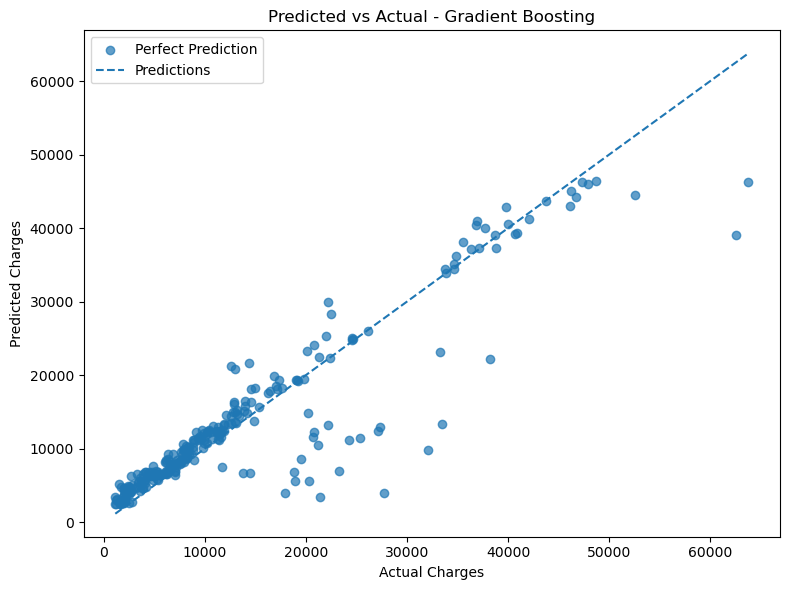

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_pred,
    alpha=0.7
)

min_value = min(y_test.min(), best_pred.min())
max_value = max(y_test.max(), best_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title(f"Predicted vs Actual - {best_model_name}")
plt.legend(["Perfect Prediction", "Predictions"])

plt.tight_layout()
plt.show()

## Residual Analysis

Residuals are the differences between the actual target values and the predicted values.

Residual = Actual Value − Predicted Value

Residual analysis helps identify whether the model makes systematic prediction errors.

In [48]:
residuals = y_test - best_pred

print("Residual Mean:", residuals.mean())
print("Residual Standard Deviation:", residuals.std())

Residual Mean: 81.37481278541871
Residual Standard Deviation: 4913.355588689384


## Residual Plot

The residual plot shows the relationship between predicted values and residual errors.

Ideally, residuals should be distributed around zero without a clear pattern. A visible pattern may indicate that the model is not capturing some relationship in the data.

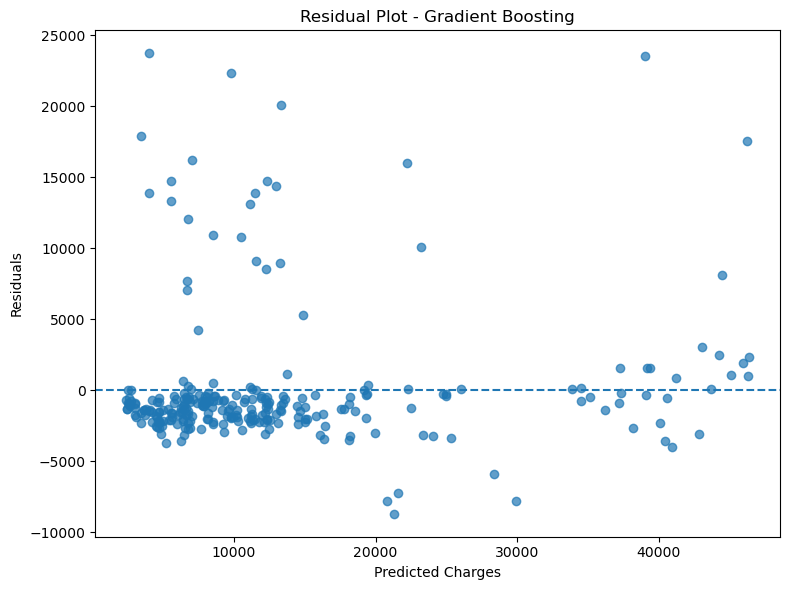

In [49]:
plt.figure(figsize=(8, 6))

plt.scatter(
    best_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - {best_model_name}")

plt.tight_layout()
plt.show()

## Feature Importance Analysis

Feature importance is examined using a tree-based regression model.

Feature importance indicates the relative contribution of each input feature to the predictions made by the tree-based model.

The most important features can provide insight into which variables have the greatest influence on the predicted insurance charges.

In [50]:
from sklearn.inspection import permutation_importance

tree_model = None
tree_model_name = None

if "Random Forest" in final_results_df["Model"].values:
    tree_model = rf_grid.best_estimator_
    tree_model_name = "Random Forest"

elif "Gradient Boosting" in final_results_df["Model"].values:
    tree_model = gb_grid.best_estimator_
    tree_model_name = "Gradient Boosting"

if tree_model is not None:
    
    permutation = permutation_importance(
        tree_model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42,
        scoring="r2",
        n_jobs=-1
    )
    
    feature_importance_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": permutation.importances_mean
    })
    
    feature_importance_df = feature_importance_df.sort_values(
        by="Importance",
        ascending=False
    )
    
    display(feature_importance_df)

,Feature,Importance
4,smoker,1.481621
2,bmi,0.239902
0,age,0.145052
6,bmi_age,0.061971
3,children,0.020207
5,region,0.002862
1,sex,-0.002064


## Feature Importance Visualization

The feature importance values are visualized to identify which input variables contribute most to the predictions of the tree-based regression model.

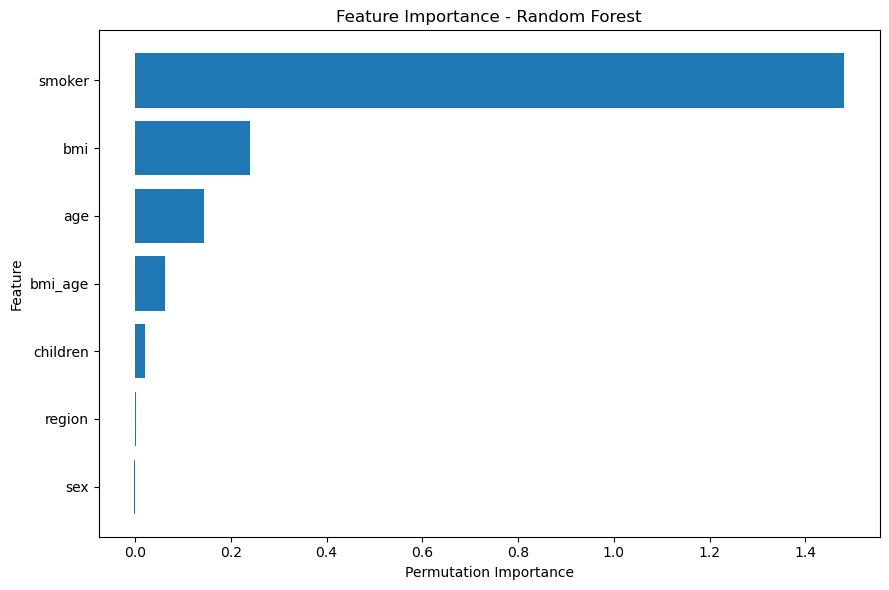

In [51]:
plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title(f"Feature Importance - {tree_model_name}")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Hyperparameter Tuning Summary

Random Forest and Gradient Boosting were optimized using GridSearchCV.

The tuned models are compared with their corresponding baseline models using the R² score. The improvement value represents the difference between the tuned and baseline R² scores.

In [52]:
tuning_summary = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting"
    ],
    "Baseline R2": [
        baseline_rf_r2,
        baseline_gb_r2
    ],
    "Tuned R2": [
        rf_r2,
        gb_r2
    ],
    "R2 Improvement": [
        rf_r2_improvement,
        gb_r2_improvement
    ]
})

display(tuning_summary)

,Model,Baseline R2,Tuned R2,R2 Improvement
0,Random Forest,0.829627,0.833601,0.003974
1,Gradient Boosting,0.833127,0.838508,0.005381


## Best Model Performance

The final performance of the selected regression model is reported using R², RMSE, and MAE on the held-out test set.

These metrics provide a quantitative summary of the predictive performance of the final model.

In [53]:
best_row = final_results_df.iloc[0]

print("Best Model:", best_row["Model"])
print("R2:", best_row["R2"])
print("RMSE:", best_row["RMSE"])
print("MAE:", best_row["MAE"])

if "CV Mean R2" in final_results_df.columns:
    print("5-Fold CV Mean R2:", best_row["CV Mean R2"])
    print("5-Fold CV Std R2:", best_row["CV Std R2"])

Best Model: Gradient Boosting
R2: 0.8331268714644178
RMSE: 4985.898240081489
MAE: 2731.893655531466
5-Fold CV Mean R2: 0.8566749428113916
5-Fold CV Std R2: 0.020290708756857703


## Regression Track Conclusion

In this regression task, the Medical Insurance dataset was analyzed and preprocessed before training ten different regression algorithms.

The models were evaluated using R², RMSE, and MAE on the same held-out test set. Hyperparameter tuning was performed using GridSearchCV for Random Forest and Gradient Boosting.

The best-performing model was identified based on the final test-set R² score after hyperparameter tuning. Its R², RMSE, and MAE values are reported in the final model comparison table.

Five-fold cross-validation was performed on the two best-performing models to evaluate the consistency of their performance.

The predicted-vs-actual and residual plots were used to analyze the prediction behavior of the best model. Feature importance analysis was also performed using a tree-based model to understand the contribution of the input features.

Overall, the regression pipeline demonstrates the complete process from data exploration and preprocessing to model comparison, hyperparameter tuning, evaluation, cross-validation, and interpretation.


## Regression Track Checklist

The following requirements were completed for the Regression Track:

- Dataset loading and data audit
- Exploratory data analysis
- Feature distribution plots
- Target distribution
- Correlation heatmap
- At least two feature-target scatter plots
- Missing-value checking
- Duplicate checking and treatment
- Outlier checking
- Feature engineering
- Categorical encoding
- Feature scaling
- 80:20 train-test split
- Stratified splitting
- Ten required regression algorithms
- R², RMSE, and MAE comparison
- Random Forest hyperparameter tuning
- Gradient Boosting hyperparameter tuning
- Five-fold cross-validation for the top two models
- Predicted-vs-actual plot
- Residual plot
- Tree-based feature importance
- Final regression comparison table
- Final model performance
- Regression conclusion

In [64]:
print("Regression Track Completed Successfully!")
print("Total Models Evaluated:", len(results_df))
print("Top 2 Models:", top_model_names)
print("Best Model:", best_model_name)

Regression Track Completed Successfully!
Total Models Evaluated: 10
Top 2 Models: ['Gradient Boosting', 'Random Forest']
Best Model: Gradient Boosting
